# ConvNeXt V2 Tiny Transfer Learning: Real vs Fake Image Classification

This notebook fine-tunes the Hugging Face model:

`facebook/convnextv2-tiny-1k-224`

for a 2-class classification task:

- `fake`
- `real`

Expected dataset structure:

```text
dataset/
  train/
    fake/
    real/
  val/
    fake/
    real/
  test/
    fake/
    real/
```

## 1. Install dependencies

In [1]:
#!pip install -q torch torchvision transformers accelerate huggingface_hub scikit-learn tqdm pillow matplotlib wandb
import os

print(os.listdir("/kaggle/input/datasets/computervisionpro/rf-images/dataset"))

['val', 'test', 'train']


## 2. Imports and configuration

In [2]:
import json
import inspect
import random
import numpy as np
import torch

from torch.utils.data import Dataset
from torchvision.datasets import ImageFolder

from PIL import Image

from transformers import (
    AutoImageProcessor,
    ConvNextV2ForImageClassification,
    Trainer,
    TrainingArguments,
)
from huggingface_hub import login

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import wandb


In [3]:
MODEL_NAME = "facebook/convnextv2-tiny-1k-224"

# Change this path if your dataset is somewhere else.
DATA_DIR = "/kaggle/input/datasets/computervisionpro/rf-images/dataset"


EXPERIMENTS = {
    "v1": {
        "run_name": "run-v1",
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 2e-5,
    },
    "v2": {
        "run_name": "run-v2",
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 3e-5,
    },
    "v3": {
        "run_name": "run-v3",
        "batch_size": 16,
        "epochs": 5,
        "learning_rate": 1e-4,
    },
}

# Change RUN_VERSION for different iterations
RUN_VERSION = "v3"
experiment_config = EXPERIMENTS[RUN_VERSION]

BATCH_SIZE = experiment_config["batch_size"]
NUM_WORKERS = 2 if os.name != "nt" else 0
EPOCHS = experiment_config["epochs"]
LEARNING_RATE = experiment_config["learning_rate"]
WEIGHT_DECAY = 0.05

NUM_LABELS = 2
SEED = 42

WANDB_PROJECT = "mlops-assignment3"
WANDB_RUN_NAME = experiment_config["run_name"]
WANDB_VERSION = RUN_VERSION
WANDB_PLATFORM = "Kaggle"

# Fill this with your public HF repo, for example "your-username/convnextv2-real-fake".
HF_REPO_ID = "computervisionpro/convnextv2-real-fake"
PUSH_TO_HUB = True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Experiment:", RUN_VERSION, experiment_config)


Device: cuda
Experiment: v3 {'run_name': 'run-v3', 'batch_size': 16, 'epochs': 5, 'learning_rate': 0.0001}


## 3. Reproducibility

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Better reproducibility, but can be slower.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## W&B experiment tracking


In [5]:
from kaggle_secrets import UserSecretsClient

os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_MODE"] = "online"
# os.environ["WANDB_NOTEBOOK_NAME"] = "kaggle"

user_secrets = UserSecretsClient()


# def get_kaggle_secret(*names):
#     last_error = None
#     for name in names:
#         try:
#             return user_secrets.get_secret(name)
#         except Exception as error:
#             last_error = error
#     raise RuntimeError(f"Could not load any Kaggle secret from: {names}") from last_error


In [6]:
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
WANDB_API_KEY = user_secrets.get_secret("WAND_DB")

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["WANDB_API_KEY"] = WANDB_API_KEY

login(token=HF_TOKEN)
wandb.login(key=WANDB_API_KEY)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


True

In [7]:
wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "model": MODEL_NAME,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "version": WANDB_VERSION,
        "platform": WANDB_PLATFORM,
        "seed": SEED,
        "num_labels": NUM_LABELS,
        "dataset_dir": DATA_DIR,
        "device": device,
        "hf_repo_id": HF_REPO_ID,
        "push_to_hub": PUSH_TO_HUB,
        "training_scope": "classifier_only",
    },
    reinit=True,
)


## 4. Label mapping

`ImageFolder` sorts class folder names alphabetically.  
If your folders are named `fake` and `real`, the mapping should be:

```python
{'fake': 0, 'real': 1}
```

In [8]:
expected_mapping = {"fake": 0, "real": 1}


## 5. Load Hugging Face image processor

In [9]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
processor

preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ConvNextImageProcessorFast {
  "crop_pct": 0.875,
  "data_format": "channels_first",
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ConvNextImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}

## 6. Dataset transform

In [10]:
class HFImageTransform:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, image):
        image = image.convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        return inputs["pixel_values"].squeeze(0)

transform = HFImageTransform(processor)

## 7. Load datasets

In [11]:
train_dir = os.path.join(DATA_DIR, "train")
val_dir = os.path.join(DATA_DIR, "val")
test_dir = os.path.join(DATA_DIR, "test")

train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

print("Class mapping from ImageFolder:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

wandb.config.update(
    {
        "class_to_idx": train_dataset.class_to_idx,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
    },
    allow_val_change=True,
)


Class mapping from ImageFolder: {'fake': 0, 'real': 1}
Train size: 2000
Val size: 400
Test size: 200


In [12]:
if val_dataset.class_to_idx != train_dataset.class_to_idx:
    raise ValueError(f"Validation mapping {val_dataset.class_to_idx} does not match train mapping {train_dataset.class_to_idx}")

if test_dataset.class_to_idx != train_dataset.class_to_idx:
    raise ValueError(f"Test mapping {test_dataset.class_to_idx} does not match train mapping {train_dataset.class_to_idx}")

label2id = dict(train_dataset.class_to_idx)
id2label = {idx: label for label, idx in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]

if label2id != expected_mapping:
    print("WARNING: Your folder-to-label mapping is different from expected.")
    print("Expected:", expected_mapping)
    print("Found:", label2id)
    print("The notebook will use the ImageFolder mapping shown above for training, reports, and W&B logs.")
else:
    print("Label mapping looks correct.")

with open("id2label.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in id2label.items()}, f, indent=2)

print("Using class names:", class_names)
print("Saved label mapping to id2label.json")
wandb.save("id2label.json")


Label mapping looks correct.
Using class names: ['fake', 'real']
Saved label mapping to id2label.json


['/kaggle/working/wandb/run-20260607_143039-4wwnjdhv/files/id2label.json']

## 8. Hugging Face Trainer datasets


In [13]:
class ImageFolderTrainerDataset(Dataset):
    def __init__(self, image_folder):
        self.image_folder = image_folder

    def __len__(self):
        return len(self.image_folder)

    def __getitem__(self, idx):
        pixel_values, label = self.image_folder[idx]
        return {
            "pixel_values": pixel_values,
            "labels": label,
        }


#

train_hf_dataset = ImageFolderTrainerDataset(train_dataset)
val_hf_dataset = ImageFolderTrainerDataset(val_dataset)
test_hf_dataset = ImageFolderTrainerDataset(test_dataset)

print("datasets :", len(train_hf_dataset), len(val_hf_dataset), len(test_hf_dataset))

datasets : 2000 400 200


## 9. Visualize a few training images

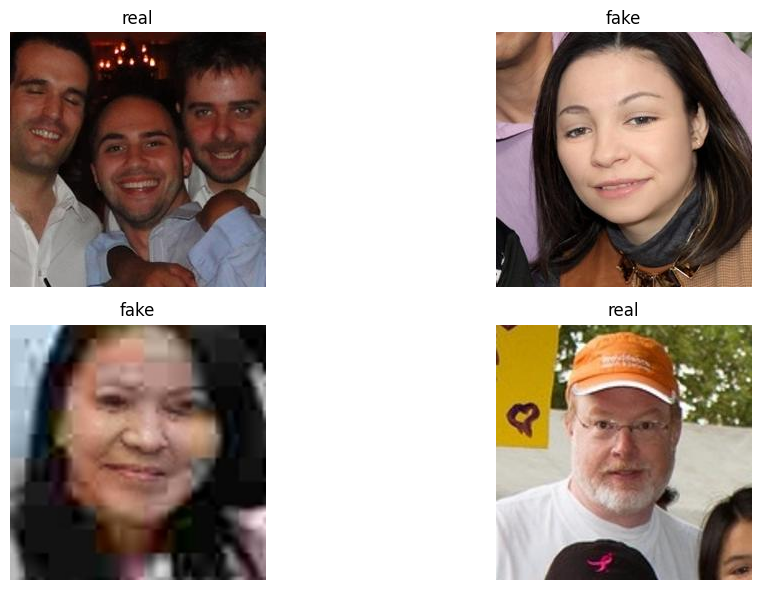

In [14]:
#import random
def show_batch(dataset, n=6):
    plt.figure(figsize=(12, 6))

    for i in range(4):
        image_path, label = dataset.samples[random.choice(range(len(dataset)))]
        img = Image.open(image_path).convert("RGB")

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(id2label[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=4)

## 10. Load ConvNeXt V2 Tiny model

In [15]:
model = ConvNextV2ForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS, # fake and real
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(device)
print("Model loaded.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ConvNextV2ForImageClassification LOAD REPORT from: facebook/convnextv2-tiny-1k-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded.


## 11. Trainer metrics and argument helpers


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }


def count_trainable_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_percent = 100 * trainable_params / total_params
    return trainable_params, total_params, trainable_percent


def make_training_args(output_dir, run_name, epochs, learning_rate):
    kwargs = {
        "output_dir": output_dir,
        "num_train_epochs": epochs,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "learning_rate": learning_rate,
        "weight_decay": WEIGHT_DECAY,
        "save_strategy": "epoch",
        "logging_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_f1",
        "greater_is_better": True,
        "report_to": "wandb",
        "run_name": run_name,
        "remove_unused_columns": False,
        "save_total_limit": 1,
        "seed": SEED,
        "fp16": device == "cuda",
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**kwargs)


def make_optimizer(model, learning_rate):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )


def freeze_all_except(model, trainable_name_patterns):
    for param in model.parameters():
        param.requires_grad = False

    for name, param in model.named_parameters():
        if any(pattern in name for pattern in trainable_name_patterns):
            param.requires_grad = True

    trainable_params, total_params, trainable_percent = count_trainable_parameters(model)
    print(f"Trainable parameters: {trainable_params:,} ({trainable_percent:.2f}%)")
    print(f"Total parameters:     {total_params:,}")
    return trainable_params, total_params, trainable_percent


## 12. Trainer history helpers


In [17]:
def image_data_collator(features):
    return {
        "pixel_values": torch.stack([feature["pixel_values"] for feature in features]),
        "labels": torch.tensor([feature["labels"] for feature in features], dtype=torch.long),
    }


def collect_trainer_history(*trainers):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    for trainer in trainers:
        for record in trainer.state.log_history:
            if "loss" in record and "eval_loss" not in record:
                history["train_loss"].append(record["loss"])
            if "eval_loss" in record:
                history["val_loss"].append(record["eval_loss"])
                history["val_acc"].append(record.get("eval_accuracy"))
                history["val_f1"].append(record.get("eval_f1"))

    return history


## 13. Train classifier head with Hugging Face Trainer


In [18]:
best_model_path = "best_convnextv2_real_fake.pt"

print("Training classifier head only with Hugging Face Trainer...")
trainable_patterns = ["classifier"]
trainable_params, total_params, trainable_percent = freeze_all_except(model, trainable_patterns)

wandb.config.update(
    {
        "trainable_patterns": trainable_patterns,
        "trainable_params": trainable_params,
        "trainable_percent": trainable_percent,
    },
    allow_val_change=True,
)

training_args = make_training_args(
    output_dir=f"./results-{RUN_VERSION}-classifier-only",
    run_name=WANDB_RUN_NAME,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
)

optimizer = make_optimizer(model, LEARNING_RATE)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf_dataset,
    eval_dataset=val_hf_dataset,
    data_collator=image_data_collator,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None),
)

train_result = trainer.train()
val_metrics = trainer.evaluate()

best_val_acc = val_metrics["eval_accuracy"]
best_val_f1 = val_metrics["eval_f1"]
torch.save(model.state_dict(), best_model_path)

wandb.run.summary["best_val_acc"] = best_val_acc
wandb.run.summary["best_val_f1"] = best_val_f1
# wandb.log(
#     {
#         "phase/classifier_train_runtime": train_result.metrics.get("train_runtime"),
#         "phase/classifier_eval_accuracy": best_val_acc,
#         "phase/classifier_eval_f1": best_val_f1,
#     }
# )

history = collect_trainer_history(trainer)

print(f"Validation accuracy: {best_val_acc:.4f}")
print(f"Validation F1:       {best_val_f1:.4f}")
print("Saved best classifier-only model!")


Training classifier head only with Hugging Face Trainer...
Trainable parameters: 1,538 (0.01%)
Total parameters:     27,868,034


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.632299,0.667559,0.595000,0.594838
2,0.552784,0.638201,0.660000,0.659148
3,0.506977,0.624177,0.682500,0.679453
4,0.482052,0.617442,0.687500,0.684182
5,0.471716,0.614764,0.690000,0.686544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Validation accuracy: 0.6900
Validation F1:       0.6865
Saved best classifier-only model!


## 14. Plot training history


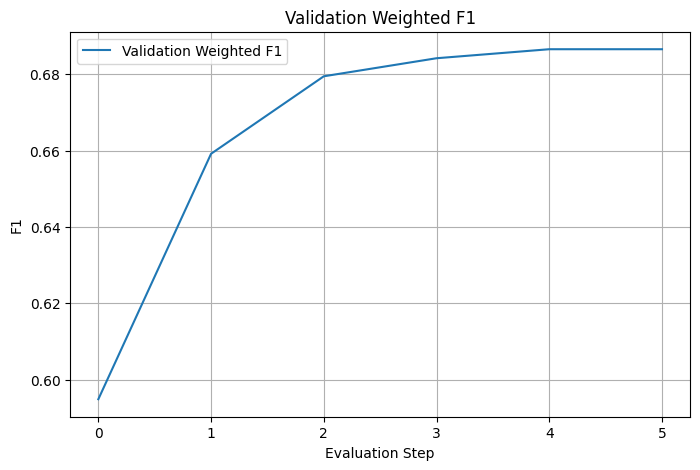

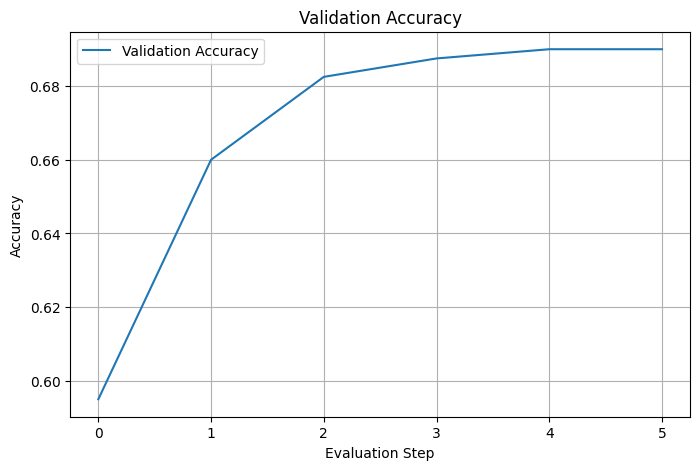

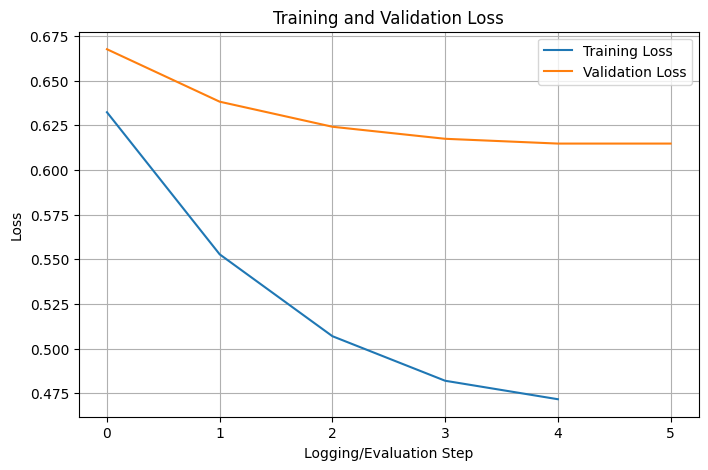

In [19]:
fig_f1 = plt.figure(figsize=(8, 5))
plt.plot(history["val_f1"], label="Validation Weighted F1")
plt.xlabel("Evaluation Step")
plt.ylabel("F1")
plt.title("Validation Weighted F1")
plt.legend()
plt.grid(True)

plt.show()

fig_acc = plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Evaluation Step")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

fig_loss = plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Logging/Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


## 15. Test evaluation


In [20]:
print("Loading best model...")
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_output = trainer.predict(test_hf_dataset, metric_key_prefix="test")
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)
test_metrics = test_output.metrics

test_loss = test_metrics["test_loss"]
test_acc = test_metrics["test_accuracy"]
test_weighted_f1 = test_metrics["test_f1"]

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

print("\nClassification Report:")
report_text = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    zero_division=0,
)
print(report_text)

report = classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)

wandb.log(
    {
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1": test_weighted_f1,
        "test/macro_f1": report["macro avg"]["f1-score"],
        "test/weighted_f1": test_weighted_f1,
        "test/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=test_labels,
            preds=test_preds,
            class_names=class_names,
        ),
    }
)
wandb.run.summary["test_accuracy"] = test_acc
wandb.run.summary["test_f1"] = test_weighted_f1
wandb.run.summary["test_macro_f1"] = report["macro avg"]["f1-score"]
wandb.save(best_model_path)


Loading best model...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test Loss: 0.5090
Test Accuracy: 0.7900
Test Weighted F1: 0.7897

Classification Report:
              precision    recall  f1-score   support

        fake       0.77      0.83      0.80       100
        real       0.82      0.75      0.78       100

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200


Confusion Matrix:
[[83 17]
 [25 75]]


['/kaggle/working/wandb/run-20260607_143039-4wwnjdhv/files/best_convnextv2_real_fake.pt']

## 16. Predict on one image


In [21]:
def predict_image(image_path, model, processor, device, id2label):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_id].item()

    return id2label[pred_id], confidence


# Example:
# image_path = "dataset/test/fake/example.jpg"
# label, confidence = predict_image(image_path, model, processor, device, id2label)
# print("Prediction:", label)
# print("Confidence:", confidence)

## 17. Save final Hugging Face model format


In [22]:
SAVE_DIR = "convnextv2_real_fake_model"

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

if PUSH_TO_HUB:
    if HF_REPO_ID.startswith("your-username/"):
        raise ValueError("Set HF_REPO_ID to your real public Hugging Face repo before pushing.")

    model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    processor.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
    hf_model_url = f"https://huggingface.co/{HF_REPO_ID}"
    wandb.run.summary["huggingface_model"] = hf_model_url
    print("Pushed model to:", hf_model_url)
else:
    print("PUSH_TO_HUB is False. Set it to True after updating HF_REPO_ID to publish the model.")

model_artifact = wandb.Artifact(
    "convnextv2-real-fake-model",
    type="model",
    metadata={
        "model_name": MODEL_NAME,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "test_f1": test_weighted_f1,
        "classes": class_names,
        "hf_repo_id": HF_REPO_ID if PUSH_TO_HUB else None,
    },
)
model_artifact.add_dir(SAVE_DIR)
wandb.log_artifact(model_artifact)
wandb.finish()

print(f"Saved model and processor to: {SAVE_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Pushed model to: https://huggingface.co/computervisionpro/convnextv2-real-fake
Saved model and processor to: convnextv2_real_fake_model


In [23]:
RUN_VERSION

'v3'

----